# DCGAN 예제: CIFAR-10 실제 이미지로 학습

이번에는 실제 이미지 데이터셋인 **CIFAR-10**으로 GAN을 학습합니다.

- 이미지 크기: 32×32 RGB
- 실제 이미지: CIFAR-10
- latent vector: `z ~ N(0, 1)`
- Generator: `z -> fake image`
- Discriminator: `image -> real/fake score`
- `for real_images, _ in dataloader:`가 데이터 전체를 한 번 돌면 **1 epoch**입니다.


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. CIFAR-10 데이터셋

`Normalize((0.5,...), (0.5,...))`로 픽셀 범위를 대략 `[-1, 1]`로 바꿉니다.
Generator 마지막 출력이 `Tanh()`이기 때문에 범위를 맞춰주는 것입니다.


In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

print('dataset size:', len(dataset))
print('batches per epoch:', len(dataloader))


100%|██████████| 170M/170M [13:32<00:00, 210kB/s]  


dataset size: 50000
batches per epoch: 391


## 2. 실제 이미지 확인


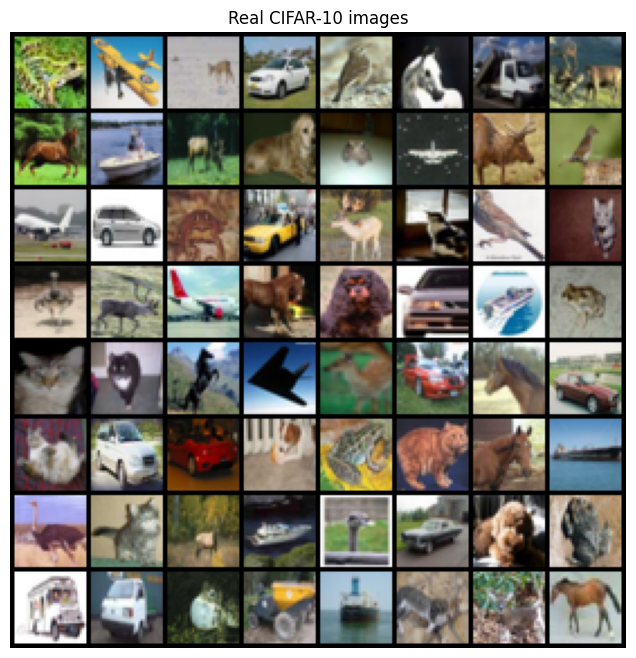

batch shape: torch.Size([128, 3, 32, 32])


In [3]:
real_images, labels = next(iter(dataloader))

grid = make_grid(real_images[:64], nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Real CIFAR-10 images')
plt.show()

print('batch shape:', real_images.shape)


## 3. Generator

latent vector `z`의 shape은 `(batch, 100, 1, 1)`입니다.

`ConvTranspose2d`를 이용해서
`1×1 -> 4×4 -> 8×8 -> 16×16 -> 32×32`로 이미지를 키웁니다.


In [4]:
latent_dim = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),  # 1 -> 4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),         # 4 -> 8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),         # 8 -> 16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),           # 16 -> 32
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


## 4. Discriminator

실제 이미지든 가짜 이미지든 `(3, 32, 32)` 이미지를 받아 하나의 logit 값으로 줄입니다.
`BCEWithLogitsLoss`를 쓰므로 마지막에 `Sigmoid()`를 넣지 않습니다.


In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),                   # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),                 # 16 -> 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),                 # 8 -> 4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),                   # 4 -> 1
        )

    def forward(self, x):
        return self.net(x).view(-1)

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

print(G)
print(D)


Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2):

## 5. Loss / Optimizer


In [10]:
criterion = nn.BCEWithLogitsLoss()

g_optimizer = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)


## 6. 학습

여기서 가장 중요한 구조는 다음입니다.

```python
for epoch in range(num_epochs):
    for real_images, _ in dataloader:
        ...
```

안쪽 `for`가 CIFAR-10 전체를 한 바퀴 다 돌면 **1 epoch**가 끝납니다.


Epoch [1/20] Batch [0/391] D loss: 1.3712 G loss: 3.7051
Epoch [1/20] Batch [100/391] D loss: 0.0222 G loss: 7.2104
Epoch [1/20] Batch [200/391] D loss: 0.3732 G loss: 4.6764
Epoch [1/20] Batch [300/391] D loss: 0.8246 G loss: 2.0402


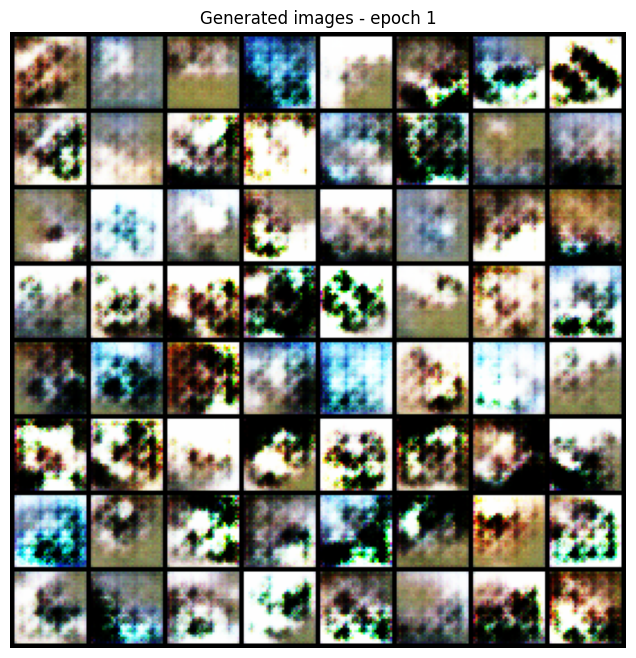

Epoch [2/20] Batch [0/391] D loss: 0.5196 G loss: 2.7546
Epoch [2/20] Batch [100/391] D loss: 0.4271 G loss: 3.3319
Epoch [2/20] Batch [200/391] D loss: 0.3334 G loss: 3.4696
Epoch [2/20] Batch [300/391] D loss: 0.7613 G loss: 3.2402
Epoch [3/20] Batch [0/391] D loss: 0.6559 G loss: 3.2295
Epoch [3/20] Batch [100/391] D loss: 0.5841 G loss: 3.2348
Epoch [3/20] Batch [200/391] D loss: 0.5553 G loss: 3.4737
Epoch [3/20] Batch [300/391] D loss: 0.2572 G loss: 3.0204
Epoch [4/20] Batch [0/391] D loss: 0.1858 G loss: 4.1988
Epoch [4/20] Batch [100/391] D loss: 0.5703 G loss: 2.8920
Epoch [4/20] Batch [200/391] D loss: 0.2742 G loss: 2.8946
Epoch [4/20] Batch [300/391] D loss: 0.2251 G loss: 5.5406
Epoch [5/20] Batch [0/391] D loss: 0.6674 G loss: 3.6014
Epoch [5/20] Batch [100/391] D loss: 1.1462 G loss: 0.4052
Epoch [5/20] Batch [200/391] D loss: 0.6121 G loss: 2.7904
Epoch [5/20] Batch [300/391] D loss: 0.7033 G loss: 3.7417


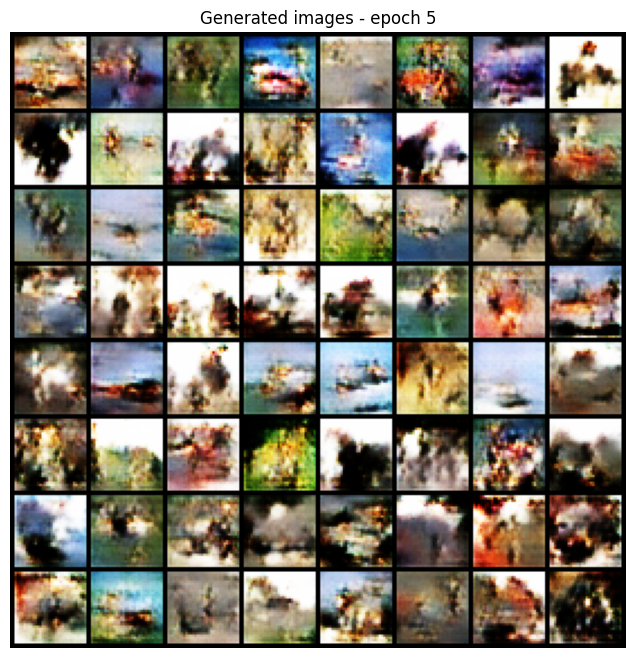

Epoch [6/20] Batch [0/391] D loss: 0.7934 G loss: 4.1864
Epoch [6/20] Batch [100/391] D loss: 0.6501 G loss: 2.1310
Epoch [6/20] Batch [200/391] D loss: 0.2185 G loss: 2.7404
Epoch [6/20] Batch [300/391] D loss: 0.1152 G loss: 4.6616
Epoch [7/20] Batch [0/391] D loss: 0.6738 G loss: 3.2982
Epoch [7/20] Batch [100/391] D loss: 0.3312 G loss: 2.7146
Epoch [7/20] Batch [200/391] D loss: 0.3784 G loss: 2.9325
Epoch [7/20] Batch [300/391] D loss: 0.7384 G loss: 2.6999
Epoch [8/20] Batch [0/391] D loss: 2.7654 G loss: 1.9879
Epoch [8/20] Batch [100/391] D loss: 0.4996 G loss: 4.1735
Epoch [8/20] Batch [200/391] D loss: 0.0928 G loss: 4.2841
Epoch [8/20] Batch [300/391] D loss: 0.1888 G loss: 3.2111
Epoch [9/20] Batch [0/391] D loss: 0.5983 G loss: 2.6825
Epoch [9/20] Batch [100/391] D loss: 0.3620 G loss: 2.7037
Epoch [9/20] Batch [200/391] D loss: 0.5383 G loss: 2.0433
Epoch [9/20] Batch [300/391] D loss: 0.4240 G loss: 5.5133
Epoch [10/20] Batch [0/391] D loss: 0.7579 G loss: 1.9480
Epoch 

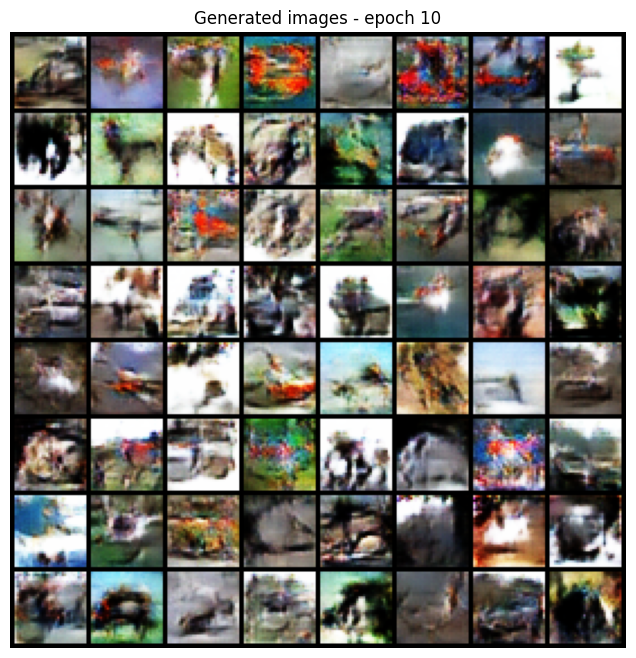

Epoch [11/20] Batch [0/391] D loss: 0.3921 G loss: 2.8650
Epoch [11/20] Batch [100/391] D loss: 0.3179 G loss: 4.5729
Epoch [11/20] Batch [200/391] D loss: 0.1022 G loss: 3.5643
Epoch [11/20] Batch [300/391] D loss: 0.2766 G loss: 2.3331
Epoch [12/20] Batch [0/391] D loss: 0.2954 G loss: 4.7634
Epoch [12/20] Batch [100/391] D loss: 0.5738 G loss: 5.5362
Epoch [12/20] Batch [200/391] D loss: 2.0932 G loss: 1.4444
Epoch [12/20] Batch [300/391] D loss: 0.3899 G loss: 5.0416
Epoch [13/20] Batch [0/391] D loss: 0.1374 G loss: 3.9138
Epoch [13/20] Batch [100/391] D loss: 0.1985 G loss: 3.2185
Epoch [13/20] Batch [200/391] D loss: 0.2130 G loss: 2.9793
Epoch [13/20] Batch [300/391] D loss: 0.2740 G loss: 3.9081
Epoch [14/20] Batch [0/391] D loss: 0.2389 G loss: 4.0369
Epoch [14/20] Batch [100/391] D loss: 0.6165 G loss: 2.1126
Epoch [14/20] Batch [200/391] D loss: 0.4765 G loss: 3.6958
Epoch [14/20] Batch [300/391] D loss: 0.3140 G loss: 4.4761
Epoch [15/20] Batch [0/391] D loss: 0.3299 G los

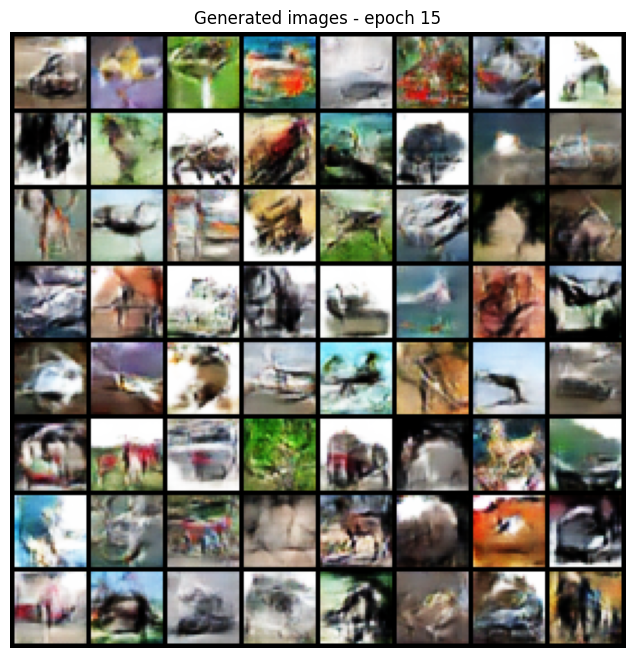

Epoch [16/20] Batch [0/391] D loss: 0.3768 G loss: 5.2371
Epoch [16/20] Batch [100/391] D loss: 0.1126 G loss: 3.7034
Epoch [16/20] Batch [200/391] D loss: 0.3861 G loss: 3.0268
Epoch [16/20] Batch [300/391] D loss: 0.5194 G loss: 5.0487
Epoch [17/20] Batch [0/391] D loss: 0.3144 G loss: 2.9009
Epoch [17/20] Batch [100/391] D loss: 0.1197 G loss: 3.6614
Epoch [17/20] Batch [200/391] D loss: 0.4360 G loss: 4.7649
Epoch [17/20] Batch [300/391] D loss: 0.1134 G loss: 3.2856
Epoch [18/20] Batch [0/391] D loss: 1.1773 G loss: 7.4733
Epoch [18/20] Batch [100/391] D loss: 0.2123 G loss: 3.7256
Epoch [18/20] Batch [200/391] D loss: 0.1485 G loss: 3.7695
Epoch [18/20] Batch [300/391] D loss: 0.2722 G loss: 1.9366
Epoch [19/20] Batch [0/391] D loss: 0.1934 G loss: 3.5361
Epoch [19/20] Batch [100/391] D loss: 0.2606 G loss: 5.2631
Epoch [19/20] Batch [200/391] D loss: 0.1054 G loss: 3.9044
Epoch [19/20] Batch [300/391] D loss: 0.1040 G loss: 3.8990
Epoch [20/20] Batch [0/391] D loss: 1.3246 G los

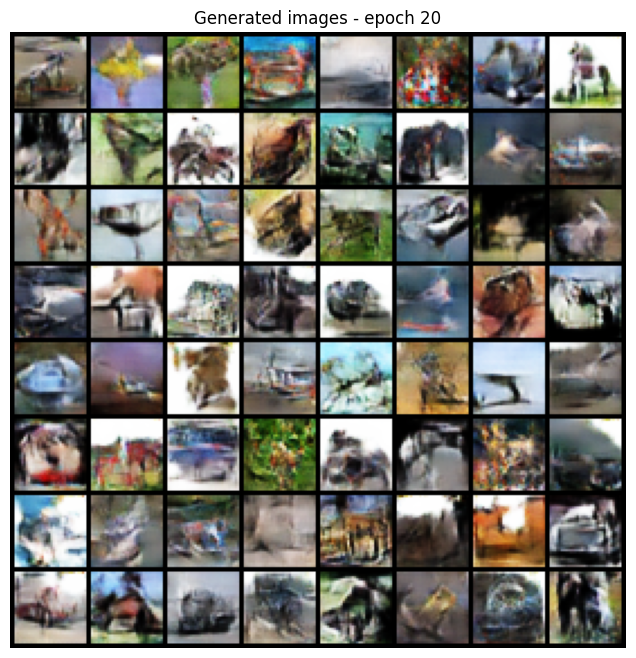

In [11]:
num_epochs = 20
g_losses = []
d_losses = []

for epoch in range(num_epochs):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        current_batch = real_images.size(0)

        # -------------------------
        # 1) Discriminator 학습
        # -------------------------
        z = torch.randn(current_batch, latent_dim, 1, 1, device=device)
        fake_images = G(z)

        real_logits = D(real_images)
        fake_logits = D(fake_images.detach())

        d_real_loss = criterion(real_logits, torch.ones_like(real_logits))
        d_fake_loss = criterion(fake_logits, torch.zeros_like(fake_logits))
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # -------------------------
        # 2) Generator 학습
        # -------------------------
        fake_logits = D(fake_images)

        # G는 D가 fake를 real(1)로 판단하도록 학습
        g_loss = criterion(fake_logits, torch.ones_like(fake_logits))

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

        if batch_idx % 100 == 0:
            print(
                f'Epoch [{epoch + 1}/{num_epochs}] '
                f'Batch [{batch_idx}/{len(dataloader)}] '
                f'D loss: {d_loss.item():.4f} '
                f'G loss: {g_loss.item():.4f}'
            )
    if epoch == 0 or (epoch + 1) % 5 == 0:
      G.eval()
      with torch.no_grad():
          generated = G(fixed_noise).cpu()
      G.train()

      grid = make_grid(generated, nrow=8, normalize=True)
      plt.figure(figsize=(8, 8))
      plt.imshow(grid.permute(1, 2, 0))
      plt.axis('off')
      plt.title(f'Generated images - epoch {epoch+1}')
      plt.show()


## 7. 생성 이미지 확인


In [ ]:
G.eval()
with torch.no_grad():
    generated = G(fixed_noise).cpu()
G.train()

grid = make_grid(generated, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Generated images')
plt.show()


## 8. Loss 확인


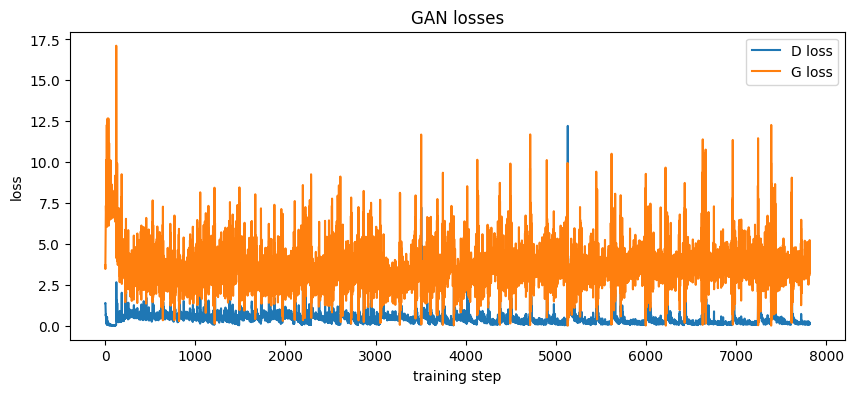

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='D loss')
plt.plot(g_losses, label='G loss')
plt.xlabel('training step')
plt.ylabel('loss')
plt.legend()
plt.title('GAN losses')
plt.show()


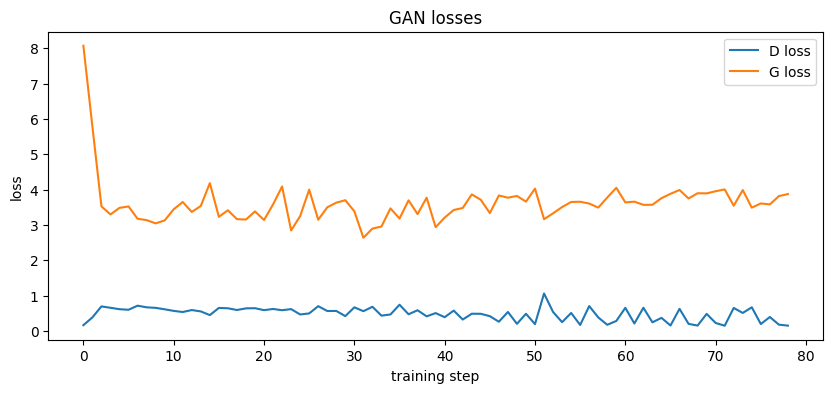

: 

In [ ]:
d_losses_compress = [sum(d_losses[i:min(len(d_losses), i+100)])/(min(len(d_losses), i+100)-i) for i in range(0, len(d_losses), 100)]
g_losses_compress = [sum(g_losses[i:min(len(g_losses), i+100)])/(min(len(g_losses), i+100)-i) for i in range(0, len(g_losses), 100)]

# type(d_losses_compress[0])
plt.figure(figsize=(10, 4))
plt.plot(d_losses_compress, label='D loss')
plt.plot(g_losses_compress, label='G loss')
plt.xlabel('training step')
plt.ylabel('loss')
plt.legend()
plt.title('GAN losses')
plt.show()


## 핵심 흐름

### 실제 이미지
`CIFAR-10 image -> D -> real인지 판단`

### 가짜 이미지
`z ~ N(0,1) -> G -> fake image -> D -> real/fake 판단`

실제 이미지는 latent vector로 encoding하지 않습니다.
기본 GAN에서 latent vector를 입력받는 것은 Generator 쪽입니다.
